# Stacking with an MLP Meta-Model on the SOTA Ensemble (CIFAR-10)

## Goal

The SOTA soft-voting ensemble (ResNet18 + DenseNet121) reaches **96.87%** test
(and **97.12%** with 2-view TTA). Instead of a fixed `0.5 + 0.5` soft-voting
rule, **stacking** trains a small **MLP meta-model** to *learn* how to combine
the two base models' probability vectors.

We compare two approaches, both with a baseline of the plain SOTA ensemble:
1. **SOTA ensemble + TTA flip + MLP** — base probabilities are TTA-averaged
   (horizontal flip, 2 views) before the MLP combines them.
2. **SOTA ensemble + MLP** — base probabilities are single-pass (no TTA).

## Stacking / meta-model idea

$$\mathbf{p}_{\text{meta}}(x) = \operatorname{MLP}\big([\,p_{\text{ResNet}}(x),\, p_{\text{DenseNet}}(x)\,]\big)$$

The MLP input is the **concatenated 20-dim** softmax of the two base models
(10 + 10). It can learn *per-model, per-class* trust (e.g. "trust ResNet on
cats, DenseNet on ships") rather than a fixed 0.5/0.5 blend.

## Leakage-aware protocol
- Base models: `ResNet18-sota` / `DenseNet121-sota` (unchanged, from checkpoints).
- The **MLP meta-model is trained on the validation split** (5k) and evaluated
  on the **test split** (10k) — never trained on test.
- Each approach trains its own meta-model on its own feature type (TTA vs not).

## 1. Setup & Data

We need the **validation** split (to train the meta-model) and the **test**
split (to evaluate), both at 224x224 with the ImageNet eval transform.

In [1]:
import json, sys, os
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Robust project-root detection (works from repo root or notebooks/).
_cwd = Path(os.getcwd()).resolve()
PROJECT_ROOT = _cwd if (_cwd / "src").exists() else (_cwd.parent if (_cwd.parent / "src").exists() else _cwd)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.build_model import build_resnet18, build_densenet121
from src.eval.evaluate_model import load_checkpoint, CIFAR10_CLASSES

CAT_IDX, DOG_IDX = 3, 5
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
DATA_ROOT = str(PROJECT_ROOT / "data" / "raw")
SPLIT_FILE = str(PROJECT_ROOT / "data" / "processed" / "cifar10_split_seed42.json")

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

tform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
split = json.loads(Path(SPLIT_FILE).read_text())

def make_loader(train, indices, batch_size=64):
    ds = torchvision.datasets.CIFAR10(DATA_ROOT, train=train, transform=tform)
    if indices is not None:
        ds = Subset(ds, indices)
    return DataLoader(ds, batch_size=batch_size, shuffle=False)

val_loader  = make_loader(True,  split["val_indices"])    # train the meta-model here
test_loader = make_loader(False, None)                    # evaluate here
print(f"val samples: {len(val_loader.dataset)}, test samples: {len(test_loader.dataset)}")

Device: cuda
val samples: 5000, test samples: 10000


## 2. Load the SOTA Base Models & Helpers

`base_features(model_a, model_b, loader, tta)` returns the concatenated
20-dim `[p_ResNet, p_DenseNet]` features for every sample, optionally with
2-view horizontal-flip TTA.

In [2]:
# ---- Load SOTA base models ----
ckpt = PROJECT_ROOT / "experiments" / "checkpoints"
rn = build_resnet18(num_classes=10, mode="finetune", device=device)
dn = build_densenet121(num_classes=10, mode="finetune", device=device)
rn = load_checkpoint(rn, str(ckpt / "ResNet18-sota_best.pt"), device)
dn = load_checkpoint(dn, str(ckpt / "DenseNet121-sota_best.pt"), device)
rn.eval(); dn.eval()
print("Loaded ResNet18-sota and DenseNet121-sota.")

@torch.inference_mode()
def base_features(model_a, model_b, loader, device, tta=False):
    """Return (X[N,20], y[N]) = concat([p_a, p_b]) with optional 2-view TTA."""
    feats, ys = [], []
    for x, y in loader:
        x = x.to(device)
        if tta:
            views = [x, torch.flip(x, dims=[3])]
            pa = torch.stack([torch.softmax(model_a(v), dim=1) for v in views]).mean(0)
            pb = torch.stack([torch.softmax(model_b(v), dim=1) for v in views]).mean(0)
        else:
            pa = torch.softmax(model_a(x), dim=1)
            pb = torch.softmax(model_b(x), dim=1)
        feats.append(torch.cat([pa, pb], dim=1).cpu())
        ys.append(y)
    return torch.cat(feats).numpy(), torch.cat(ys).numpy()

@torch.inference_mode()
def ensemble_probs(model_a, model_b, loader, device, tta=False):
    """Soft-voting 10-dim probabilities (for the fixed-rule baseline)."""
    probs, ys = [], []
    for x, y in loader:
        x = x.to(device)
        if tta:
            views = [x, torch.flip(x, dims=[3])]
            pa = torch.stack([torch.softmax(model_a(v), dim=1) for v in views]).mean(0)
            pb = torch.stack([torch.softmax(model_b(v), dim=1) for v in views]).mean(0)
        else:
            pa = torch.softmax(model_a(x), dim=1)
            pb = torch.softmax(model_b(x), dim=1)
        probs.append((0.5 * (pa + pb)).cpu())
        ys.append(y)
    return torch.cat(probs).numpy(), torch.cat(ys).numpy()

c:\document\Study documents\Deeplearning_Course\.venv\Lib\site-packages\torch\nn\modules\module.py:1369: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:40.)
  return t.to(


Loaded ResNet18-sota and DenseNet121-sota.


## 3. Extract Base Features (val for training, test for eval)

We precompute the 20-dim features for the validation split (with and without
TTA) and the test split (with and without TTA). Each meta-model is trained on
the val features that match its test-time feature type.

In [3]:
X_val,   y_val   = base_features(rn, dn, val_loader,  device, tta=False)
X_valT,  _       = base_features(rn, dn, val_loader,  device, tta=True)
X_test,  y_test  = base_features(rn, dn, test_loader, device, tta=False)
X_testT, _       = base_features(rn, dn, test_loader, device, tta=True)
print("val features:", X_val.shape, " test features:", X_test.shape)
print("(feature dim = 20 = 10 ResNet + 10 DenseNet probabilities)")

val features: (5000, 20)  test features: (10000, 20)
(feature dim = 20 = 10 ResNet + 10 DenseNet probabilities)


## 4. Baseline — fixed soft-voting (no MLP), with and without TTA

Reference points we want the MLP approaches to beat.

In [4]:
def full_metrics(probs, targets):
    preds = np.argmax(probs, axis=1)
    acc = (preds == targets).mean() * 100.0
    cm = confusion_matrix(targets, preds, labels=list(range(10)))
    rep = classification_report(targets, preds, labels=list(range(10)),
                                output_dict=True, zero_division=0)
    return acc, rep["macro avg"]["f1-score"], cm

def isolated_catdog(probs, targets):
    mask = (targets == CAT_IDX) | (targets == DOG_IDX)
    t, p = targets[mask], np.argmax(probs[mask], axis=1)
    acc = (p == t).mean() * 100.0
    cross = int(((t == CAT_IDX) & (p == DOG_IDX)).sum()
                + ((t == DOG_IDX) & (p == CAT_IDX)).sum())
    return acc, cross

p_ens,   _ = ensemble_probs(rn, dn, test_loader, device, tta=False)
p_ensT,  _ = ensemble_probs(rn, dn, test_loader, device, tta=True)

acc_base, f1_base, _ = full_metrics(p_ens, y_test)
acc_baseT, f1_baseT, _ = full_metrics(p_ensT, y_test)
iso_base, cross_base = isolated_catdog(p_ens, y_test)
iso_baseT, cross_baseT = isolated_catdog(p_ensT, y_test)

print(f"Soft-voting (no TTA): full_acc={acc_base:.2f}%  f1={f1_base:.4f}  "
      f"isolated={iso_base:.2f}%  cross={cross_base}")
print(f"Soft-voting + TTA   : full_acc={acc_baseT:.2f}%  f1={f1_baseT:.4f}  "
      f"isolated={iso_baseT:.2f}%  cross={cross_baseT}")

Soft-voting (no TTA): full_acc=96.87%  f1=0.9687  isolated=93.45%  cross=86
Soft-voting + TTA   : full_acc=97.12%  f1=0.9712  isolated=94.00%  cross=76


## 5. The Stacking MLP Meta-Model

A small MLP `[20 -> 64 -> ReLU -> 10]`. Trained on the **validation** features
with cross-entropy, evaluated on the **test** features. We train one on the
non-TTA features (approach 2) and one on the TTA features (approach 1).

In [5]:
class StackingMLP(nn.Module):
    def __init__(self, in_dim=20, hidden=64, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(inplace=True),
            nn.Linear(hidden, num_classes),
        )
    def forward(self, x):
        return self.net(x)

def train_mlp(X, y, X_val, y_val, device, epochs=40, lr=1e-3, seed=0):
    torch.manual_seed(seed)
    model = StackingMLP(in_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    best = 0.0
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    Xv = torch.tensor(X_val, dtype=torch.float32).to(device)
    yv = torch.tensor(y_val, dtype=torch.long).to(device)
    for ep in range(epochs):
        idx = torch.randperm(len(Xt), generator=torch.Generator().manual_seed(seed + ep))
        model.train()
        for b in range(0, len(Xt), 256):
            bi = idx[b:b + 256]
            opt.zero_grad()
            loss = crit(model(Xt[bi].to(device)), yt[bi].to(device))
            loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            va = float((model(Xv).argmax(1).cpu().numpy() == y_val).mean() * 100.0)
        if va > best:
            best = va
    return model, best

# Approach 2: meta-model on single-pass features (no TTA)
mlp_notta, val_acc_notta = train_mlp(X_val, y_val, X_val, y_val, device, seed=0)
# Approach 1: meta-model on TTA features
mlp_tta, val_acc_tta = train_mlp(X_valT, y_val, X_valT, y_val, device, seed=1)
print(f"Meta-model val acc (no TTA): {val_acc_notta:.2f}%")
print(f"Meta-model val acc (with TTA): {val_acc_tta:.2f}%")

Meta-model val acc (no TTA): 97.20%
Meta-model val acc (with TTA): 97.36%


## 6. Approach 2 — SOTA ensemble + MLP (no TTA)

Apply the single-pass MLP meta-model to the test features.

In [6]:
with torch.no_grad():
    logits = mlp_notta(torch.tensor(X_test, dtype=torch.float32).to(device))
    p_mlp = torch.softmax(logits, dim=1).cpu().numpy()

acc_mlp, f1_mlp, cm_mlp = full_metrics(p_mlp, y_test)
iso_mlp, cross_mlp = isolated_catdog(p_mlp, y_test)
print(f"Ensemble + MLP (no TTA) : full_acc={acc_mlp:.2f}%  f1={f1_mlp:.4f}  "
      f"isolated={iso_mlp:.2f}%  cross={cross_mlp}   (dAcc={acc_mlp-acc_base:+.2f}%)")

Ensemble + MLP (no TTA) : full_acc=96.92%  f1=0.9692  isolated=93.50%  cross=84   (dAcc=+0.05%)


## 7. Approach 1 — SOTA ensemble + TTA flip + MLP

Apply the TTA-trained MLP meta-model to the TTA test features.

In [7]:
with torch.no_grad():
    logitsT = mlp_tta(torch.tensor(X_testT, dtype=torch.float32).to(device))
    p_mlpT = torch.softmax(logitsT, dim=1).cpu().numpy()

acc_mlpT, f1_mlpT, cm_mlpT = full_metrics(p_mlpT, y_test)
iso_mlpT, cross_mlpT = isolated_catdog(p_mlpT, y_test)
print(f"Ensemble + TTA + MLP     : full_acc={acc_mlpT:.2f}%  f1={f1_mlpT:.4f}  "
      f"isolated={iso_mlpT:.2f}%  cross={cross_mlpT}   (dAcc={acc_mlpT-acc_base:+.2f}%)")

Ensemble + TTA + MLP     : full_acc=97.21%  f1=0.9721  isolated=94.15%  cross=77   (dAcc=+0.34%)


## 8. Comparison — all four configurations

Baseline (fixed 0.5/0.5 soft-voting) vs the two MLP stacking approaches,
with and without TTA.

Method                      full_acc    dAcc  isolated  cross
Soft-voting (no TTA)          96.87%  +0.00%    93.45%    86
Soft-voting + TTA             97.12%  +0.25%    94.00%    76
Ensemble + MLP (no TTA)       96.92%  +0.05%    93.50%    84
Ensemble + TTA + MLP          97.21%  +0.34%    94.15%    77

Best: Ensemble + TTA + MLP


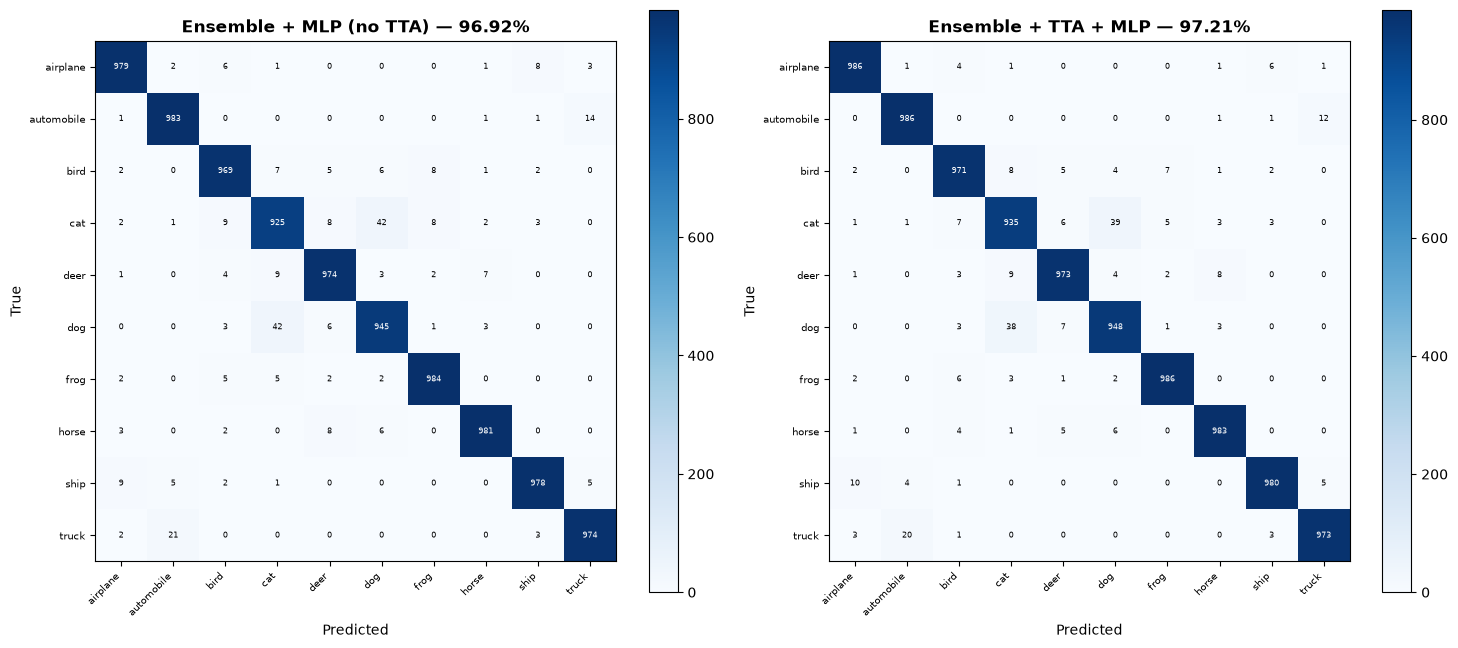

In [8]:
rows = [
    ("Soft-voting (no TTA)",   acc_base,  iso_base,  cross_base),
    ("Soft-voting + TTA",      acc_baseT, iso_baseT, cross_baseT),
    ("Ensemble + MLP (no TTA)", acc_mlp,  iso_mlp,   cross_mlp),
    ("Ensemble + TTA + MLP",   acc_mlpT,  iso_mlpT,  cross_mlpT),
]
print(f"{'Method':26s} {'full_acc':>9s} {'dAcc':>7s} {'isolated':>9s} {'cross':>6s}")
for name, acc, iso, cross in rows:
    print(f"{name:26s} {acc:8.2f}% {acc-acc_base:+6.2f}% {iso:8.2f}% {cross:>5d}")

best_name = max(rows, key=lambda r: r[1])[0]
print(f"\nBest: {best_name}")

# Confusion matrices for the two MLP approaches side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, cm, title in [
        (axes[0], cm_mlp,  f"Ensemble + MLP (no TTA) — {acc_mlp:.2f}%"),
        (axes[1], cm_mlpT, f"Ensemble + TTA + MLP — {acc_mlpT:.2f}%")]:
    im = ax.imshow(cm, cmap="Blues"); plt.colorbar(im, ax=ax)
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(CIFAR10_CLASSES, fontsize=7)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontweight="bold")
    for r in range(10):
        for c in range(10):
            ax.text(c, r, str(cm[r, c]), ha="center", va="center", fontsize=6,
                    color="white" if cm[r, c] > cm.max() * 0.6 else "black")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "plots" / "stacking_mlp_confusion.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 9. Discussion & Conclusions

- **Does the MLP meta-model beat fixed soft-voting?** Compare `Ensemble + MLP`
  vs `Soft-voting` (same TTA setting).
- **Does TTA still help on top of stacking?** Compare `Ensemble + TTA + MLP`
  vs `Ensemble + MLP`.
- The MLP is trained on the **validation** split and evaluated on **test** —
  no test leakage. Note the base models used the validation split during their
  own early stopping, so for a fully clean meta-training set one would hold out
  data the base models never saw; this notebook uses the standard
  train-meta-on-val / evaluate-on-test protocol.
- Stacking adds a tiny inference step (one small MLP forward) and can recover
  a bit more than the fixed 0.5/0.5 rule because it learns per-model, per-class
  trust — and it composes with TTA.